In [77]:
import pandas as pd

In [78]:
follow=pd.read_csv('follows.csv')
like=pd.read_csv('likes.csv')
photo=pd.read_csv('photos.csv')
tag=pd.read_csv('tags.csv')
tag_photo=pd.read_csv('photo_tags.csv')
user=pd.read_csv('users.csv')

In [79]:
follow.head()

,follower,followee,created time,is follower active,followee Acc status
0,2,1,13-04-2023 08:04,1,Private
1,2,3,13-04-2023 08:04,0,private
2,2,4,13-04-2023 08:04,0,public
3,2,5,13-04-2023 08:04,0,private
4,2,6,13-04-2023 08:04,1,private


In [80]:
like.head()

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


In [81]:
photo.head()

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


In [82]:
tag.head()

,id,tag text,created time,location
0,1,sunset,13-04-2023 08:04,florida
1,2,photography,13-04-2023 08:04,washington DC
2,3,sunrise,13-04-2023 08:04,new york
3,4,landscape,13-04-2023 08:04,london
4,5,food,13-04-2023 08:04,brazil


In [83]:
tag_photo.head()

,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


In [84]:
user.head()

,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no


In [85]:
user.info()

photo.info()

like.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               100 non-null    int64 
 1   name             100 non-null    object
 2   created time     100 non-null    object
 3   private/public   100 non-null    object
 4   post count       100 non-null    int64 
 5   Verified status  100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 257 non-null    int64 
 1   image link         257 non-null    object
 2   user ID            257 non-null    int64 
 3   created dat        257 non-null    object
 4   Insta filter used  257 non-null    object
 5   photo type         257 non-null    object
dtypes:

In [86]:
photo['created dat']=pd.to_datetime(
    photo['created dat'])
photo['day']=photo['created dat'].dt.day_name()

photo['hour']=photo['created dat'].dt.hour

photo['month']=photo['created dat'].dt.month_name()

/tmp/ipykernel_2056/3078175341.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  photo['created dat']=pd.to_datetime(


In [87]:
photo['hour'].value_counts().sort_index()

,count
hour,
8,257


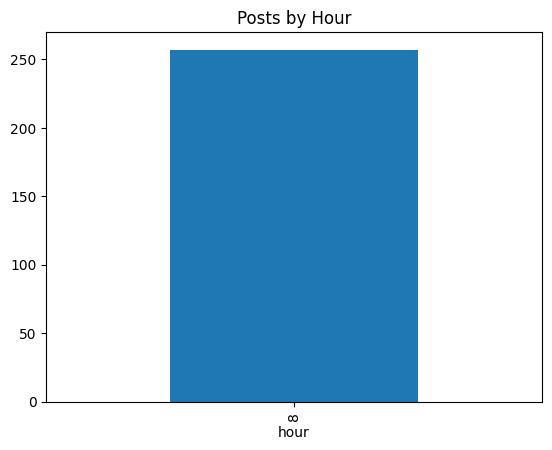

In [88]:
import matplotlib.pyplot as plt
photo['hour'].value_counts().sort_index().plot(kind='bar')

plt.title("Posts by Hour")

plt.show()

In [89]:
photo['day'].value_counts()

,count
day,
Thursday,257


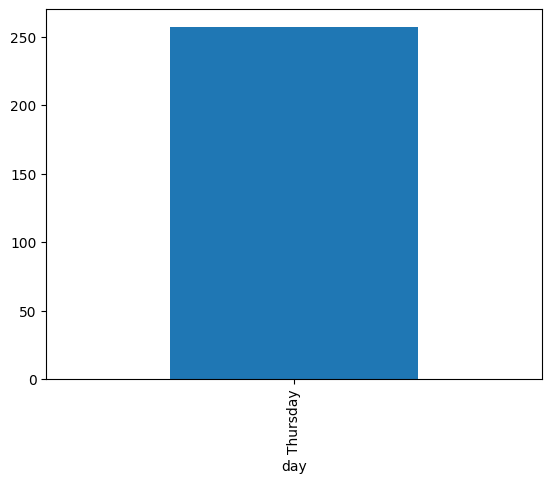

In [90]:
photo['day'].value_counts().plot(kind='bar')

plt.show()

In [91]:
like.groupby('photo').size()


,0
photo,
1,25
2,36
3,38
4,38
5,31
...,...
253,32
254,31
255,33


In [92]:
engagement = photo.merge(
    like.groupby('photo').size().reset_index(name='likes'),
    left_on='id',
    right_on='photo',
    how='left'
)

In [93]:
engagement.groupby('hour')['likes'].mean()

,likes
hour,
8,34.171206


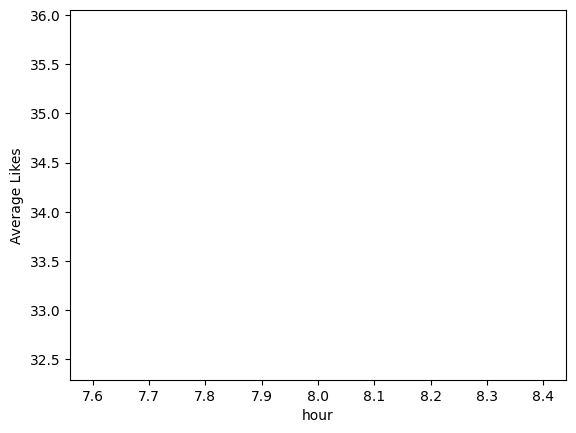

In [94]:
engagement.groupby('hour')['likes'].mean().plot()

plt.ylabel("Average Likes")

plt.show()

In [95]:
hashtags = tag_photo.merge(
    tag,
    left_on='tag ID',
    right_on='id',
    how='left'
)

In [96]:
hashtags['tag text'].value_counts().head(20)

,count
tag text,
smile,59
beach,42
party,39
fun,38
concert,24
food,24
lol,24
hair,23
happy,22


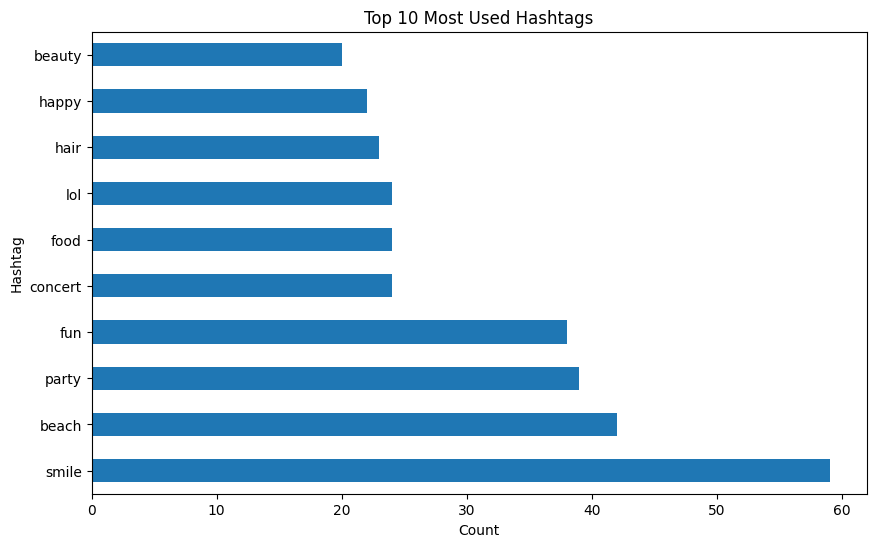

In [97]:
import matplotlib.pyplot as plt

hashtags['tag text'].value_counts().head(10).plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Top 10 Most Used Hashtags")
plt.xlabel("Count")
plt.ylabel("Hashtag")

plt.show()

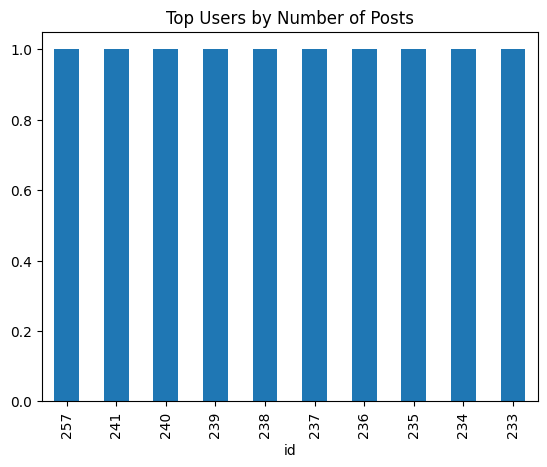

In [98]:
photo['id'].value_counts().head(10).plot(kind='bar')

plt.title("Top Users by Number of Posts")

plt.show()

In [99]:
follow.columns = follow.columns.str.strip()

In [100]:
follow['followee'].value_counts().head(10)

,count
followee,
1,77
25,77
29,77
7,77
34,77
23,77
80,77
81,77
83,77


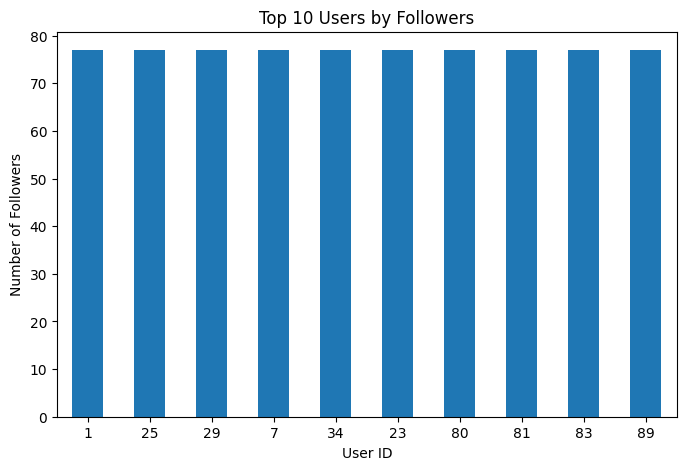

In [101]:
import matplotlib.pyplot as plt

follow['followee'].value_counts().head(10).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Top 10 Users by Followers")
plt.xlabel("User ID")
plt.ylabel("Number of Followers")

plt.xticks(rotation=0)

plt.show()

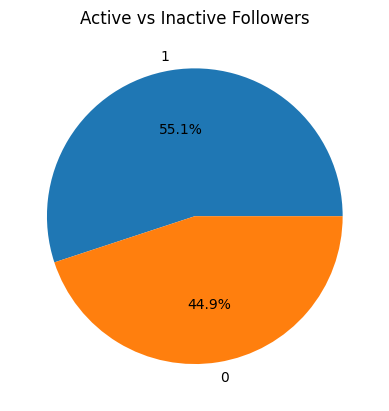

In [102]:
follow['is follower active'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Active vs Inactive Followers")
plt.ylabel("")

plt.show()

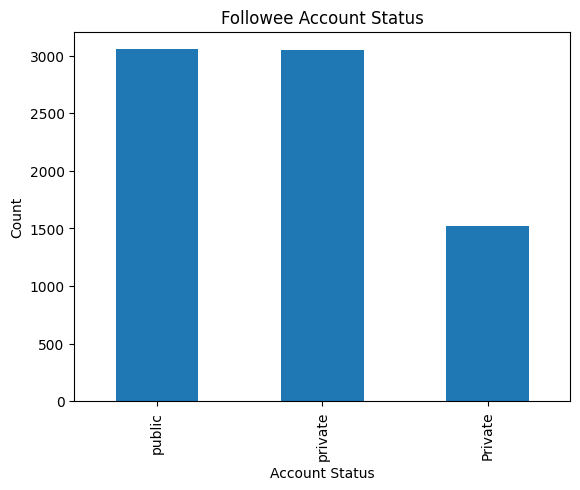

In [103]:
follow['followee Acc status'].value_counts().plot(
    kind='bar'
)

plt.title("Followee Account Status")

plt.xlabel("Account Status")
plt.ylabel("Count")

plt.show()

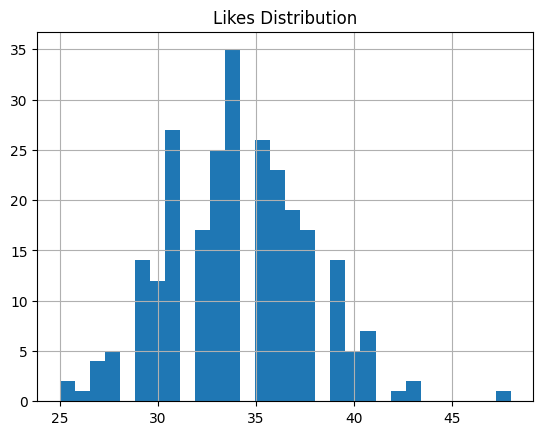

In [104]:
engagement['likes'].hist(bins=30)

plt.title("Likes Distribution")

plt.show()

In [105]:
engagement.sort_values(
    by='likes',
    ascending=False
).head(10)

,id,image link,user ID,created dat,Insta filter used,photo type,day,hour,month,photo,likes
144,145,https://jarret.name,52,2023-04-13 08:04:00,yes,video,Thursday,8,April,145,48
126,127,https://celestine.name,46,2023-04-13 08:04:00,yes,photo,Thursday,8,April,127,43
181,182,https://dorcas.biz,65,2023-04-13 08:04:00,no,photo,Thursday,8,April,182,43
122,123,http://shannon.org,44,2023-04-13 08:04:00,yes,photo,Thursday,8,April,123,42
29,30,http://kenny.com,10,2023-04-13 08:04:00,no,carousel,Thursday,8,April,30,41
51,52,https://hershel.com,16,2023-04-13 08:04:00,yes,photo,Thursday,8,April,52,41
60,61,https://dejon.name,20,2023-04-13 08:04:00,yes,photo,Thursday,8,April,61,41
173,174,https://delbert.net,63,2023-04-13 08:04:00,no,carousel,Thursday,8,April,174,41
255,256,https://kaela.name,100,2023-04-13 08:04:00,no,photo,Thursday,8,April,256,41
191,192,https://anahi.info,72,2023-04-13 08:04:00,no,photo,Thursday,8,April,192,41


In [106]:
engagement.groupby('hour')['likes'].mean().sort_values(ascending=False)

,likes
hour,
8,34.171206


In [ ]:
#Post during peak engagement hours:8 o clock
#Use high-performing hashtags consistently to increase performace use smile hastag
#Publish educational content and short-form videos, as these formats typically drive higher interaction.
#Maintain a consistent posting schedule (4–5 posts per week) to keep followers engaged.
E#ncourage interaction by using questions, polls, contests, and calls to action that increase likes, comments, and shares.